# M1 Robustness: Leave-One-Family-Out Evaluation

Tests how well **M1 (Base CNN + Multi-scale)** generalises to **unseen DGA families**.

**Protocol — for each of the 7 DGA subclasses:**
1. Remove all samples of that subclass from training & validation
2. Retrain M1 using the **best hyperparameters from the previous Optuna study**
3. Evaluate on **only** the held-out subclass samples as the test set
4. Record threshold, AUC-ROC, FPR, Precision, Recall, F1

The resulting heatmap and summary table reveal which DGA families are structurally
similar to others (easy to generalise to) and which are genuinely novel (hard).

> **Prerequisite:** cells 1–9 of `dga_three_models.ipynb` must have been run in the
> same kernel session so that `M1_MultiScale`, `DGADataSet`, `stoi`, `compute_metrics`,
> `find_best_threshold`, and `studies` are already defined. Alternatively, run the
> self-contained setup cell below.

## 1. Imports & Shared Setup

In [1]:
pip install -q optuna lightning scikit-learn torch pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 28.7 MB/s eta 0:00:00


In [2]:
import string, time, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_curve,
)
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')

# ── Vocabulary ────────────────────────────────────────────────────────────────
VOCAB      = string.ascii_lowercase + string.digits + "-."
stoi       = {ch: i + 1 for i, ch in enumerate(VOCAB)}
PAD_IDX    = 0
VOCAB_SIZE = len(stoi) + 1
NUM_WORKERS = 4
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

FINAL_EPOCHS = 20

print(f"Vocab size : {VOCAB_SIZE}")
print(f"Device     : {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Vocab size : 39
Device     : cuda


## 2. Load Dataset & Inspect Subclasses

In [3]:
dga_dataset = pd.read_csv("./dga_data.csv")
dga_dataset = dga_dataset.dropna(subset=['domain']).copy()
dga_dataset["isDGA_flag"] = (dga_dataset["isDGA"] == "dga").astype(int)

dga_dataset["subclass"] = dga_dataset["subclass"].fillna("legit")

DGA_FAMILIES = ['bamital', 'cryptolocker', 'gameoverdga', 'goz',
                'necurs', 'newgoz', 'nivdort']

print("Subclass distribution:")
print(dga_dataset["subclass"].value_counts().to_string())

Subclass distribution:
subclass
alexa           42614
legit           37384
cryptolocker    37254
newgoz           9276
gameoverdga      8461
nivdort          8456
necurs           8331
goz              6136
bamital          2086


## 3. M1 Model Definition

In [4]:
class _BaseModel(L.LightningModule):
    def __init__(self, lr: float):
        super().__init__()
        self.lr      = lr
        self.loss_fn = nn.BCEWithLogitsLoss()
        self._test_probs: list  = []
        self._test_labels: list = []

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)
        return {"optimizer": opt, "lr_scheduler": sch}

    def _step(self, batch):
        x_seq, x_ngram, y = batch
        logits = self(x_seq, x_ngram)
        loss   = self.loss_fn(logits, y)
        probs  = torch.sigmoid(logits)
        preds  = probs > 0.5
        acc    = (preds == y.bool()).float().mean()
        return loss, acc, probs, y

    def training_step(self, batch, _):
        loss, acc, _, _ = self._step(batch)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc",  acc,  prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        loss, acc, _, _ = self._step(batch)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc",  acc,  prog_bar=True)

    def on_test_epoch_start(self):
        self._test_probs, self._test_labels = [], []

    def test_step(self, batch, _):
        loss, acc, probs, labels = self._step(batch)
        self.log("test_loss", loss)
        self.log("test_acc",  acc)
        self._test_probs.append(probs.detach().cpu())
        self._test_labels.append(labels.detach().cpu())

    def on_test_epoch_end(self):
        self.all_probs  = torch.cat(self._test_probs).numpy()
        self.all_labels = torch.cat(self._test_labels).numpy()


class M1_MultiScale(_BaseModel):
    KERNEL_SIZES = [3, 5, 7]

    def __init__(self, vocab_size, embed_dim=64, num_filters=128, dropout=0.3, lr=1e-3):
        super().__init__(lr)
        self.save_hyperparameters()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs     = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding=k // 2)
            for k in self.KERNEL_SIZES
        ])
        fused = num_filters * len(self.KERNEL_SIZES)
        self.head = nn.Sequential(
            nn.Linear(fused, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 1)
        )

    def forward(self, x_seq, x_ngram=None):
        emb = self.embedding(x_seq).permute(0, 2, 1)
        pooled = torch.cat(
            [F.max_pool1d(F.relu(conv(emb)), emb.size(2)).squeeze(2)
             for conv in self.convs], dim=1
        )
        return self.head(pooled).squeeze(1)

## 4. Dataset & DataModule
The `LeaveOneFamilyDataModule` accepts explicit train/val/test DataFrames so each
LOFO fold can pass its own splits without relying on globals.

In [5]:
class DGADataSet(Dataset):
    def __init__(self, domains, labels, seq_len):
        self.domains = domains.reset_index(drop=True)
        self.labels  = labels.reset_index(drop=True)
        self.seq_len = seq_len

    def encode_domain(self, domain: str) -> torch.Tensor:
        encoded = [stoi.get(c, 0) for c in domain.lower()]
        encoded = encoded[:self.seq_len]
        encoded += [PAD_IDX] * (self.seq_len - len(encoded))
        return torch.tensor(encoded, dtype=torch.long)

    def __len__(self):
        return len(self.domains)

    def __getitem__(self, idx):
        x_seq   = self.encode_domain(self.domains.iloc[idx])
        # x_ngram placeholder (M1 ignores it, but _BaseModel._step unpacks 3 items)
        x_ngram = torch.zeros(1)
        y       = torch.tensor(self.labels.iloc[idx], dtype=torch.float32)
        return x_seq, x_ngram, y


class LeaveOneFamilyDataModule(L.LightningDataModule):
    """DataModule for a single LOFO fold."""

    def __init__(self, train_df, val_df, test_df, seq_len, batch_size):
        super().__init__()
        self.seq_len    = seq_len
        self.batch_size = batch_size
        self._train = DGADataSet(train_df["domain"], train_df["isDGA_flag"], seq_len)
        self._val   = DGADataSet(val_df["domain"],   val_df["isDGA_flag"],   seq_len)
        self._test  = DGADataSet(test_df["domain"],  test_df["isDGA_flag"],  seq_len)

    def train_dataloader(self):
        return DataLoader(self._train, batch_size=self.batch_size,
                          shuffle=True, num_workers=NUM_WORKERS)

    def val_dataloader(self):
        return DataLoader(self._val, batch_size=self.batch_size,
                          num_workers=NUM_WORKERS, persistent_workers=True)

    def test_dataloader(self):
        return DataLoader(self._test, batch_size=self.batch_size,
                          num_workers=NUM_WORKERS)

## 5. Metrics Helper

In [6]:
def find_best_threshold(probs, labels):
    thresholds = np.linspace(0.01, 0.99, 200)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f = f1_score(labels, preds, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t


def compute_metrics(probs, labels) -> dict:
    # Guard: if only one class present in labels AUC is undefined
    if len(np.unique(labels)) < 2:
        return {k: float('nan') for k in
                ["threshold", "AUC-ROC", "FPR", "Precision", "Recall", "F1",
                 "mean_latency_ms", "p99_latency_ms"]}
    threshold = find_best_threshold(probs, labels)
    preds     = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0,1]).ravel()
    return {
        "threshold"        : round(float(threshold), 4),
        "AUC-ROC"          : round(float(roc_auc_score(labels, probs)), 4),
        "FPR"              : round(float(fp / (fp + tn + 1e-9)), 4),
        "Precision"        : round(float(precision_score(labels, preds, zero_division=0)), 4),
        "Recall"           : round(float(recall_score(labels, preds, zero_division=0)), 4),
        "F1"               : round(float(f1_score(labels, preds, zero_division=0)), 4),
        "mean_latency_ms"  : float('nan'),   # filled in after inference timing
        "p99_latency_ms"   : float('nan'),   # filled in after inference timing
    }

## 6. Paste Best M1 Hyperparameters from Optuna Study

These come from `studies['M1: Multi-scale'].best_params` in `dga_three_models.ipynb`.
Replace the values below with the actual output from that study.

In [7]:

# Printed output from dga_three_models.ipynb here ──
M1_BEST = {
    'seq_len': 75,
    'embed_dim': 32,
    'num_filters': 128,
    'dropout': 0.10066290468497816,
    'lr': 0.003484453888228351,
    'batch_size': 128
  }

for k, v in M1_BEST.items():
    print(f"  {k:15s}: {v}")

  seq_len        : 75
  embed_dim      : 32
  num_filters    : 128
  dropout        : 0.10066290468497816
  lr             : 0.003484453888228351
  batch_size     : 128


## 7. Leave-One-Family-Out Training Loop

**Split logic per fold:**
- **Exclude** all rows where `subclass == held_out_family` from train/val
- **Train set**: remaining data minus 10% val, stratified by label
- **Val set**: 10% of remaining data, stratified by label
- **Test set**: *only* the held-out family rows (all of them — DGA only)
  combined with a matched sample of benign domains so the test set is balanced

This gives a clean zero-shot generalisation signal: the model has never seen
any domain from the held-out family during training.

In [8]:
lofo_results   = {}   # family -> metrics dict
lofo_models    = {}   # family -> trained model (for ROC plots)

seq_len    = M1_BEST["seq_len"]
batch_size = M1_BEST["batch_size"]
benign_df  = dga_dataset[dga_dataset["subclass"] == "legit"].copy()

for family in DGA_FAMILIES:
    print(f"\n{'━'*60}")
    print(f"  Held-out family: {family.upper()}")
    print(f"{'━'*60}")

    # ── Build held-out test set ───────────────────────────────────────────────
    held_out_dga = dga_dataset[dga_dataset["subclass"] == family].copy()
    n_held       = len(held_out_dga)

    # Sample equal number of benign for a balanced binary test
    benign_test  = benign_df.sample(n=min(n_held, len(benign_df)),
                                    random_state=SEED)
    test_df      = pd.concat([held_out_dga, benign_test]).sample(
                        frac=1, random_state=SEED).reset_index(drop=True)

    print(f"  Test  : {n_held:,} DGA + {len(benign_test):,} benign = {len(test_df):,} total")

    # ── Build train / val (exclude held-out family) ───────────────────────────
    trainval_df = dga_dataset[
        (dga_dataset["subclass"] != family)
    ].copy()

    # Further exclude the benign rows used in test to avoid any leakage
    trainval_df = trainval_df[~trainval_df.index.isin(benign_test.index)]

    train_df, val_df = train_test_split(
        trainval_df, test_size=0.1, random_state=SEED,
        stratify=trainval_df["isDGA_flag"]
    )
    print(f"  Train : {len(train_df):,}  |  Val: {len(val_df):,}")
    print(f"  DGA balance (train): {train_df['isDGA_flag'].mean():.2%}")

    # ── DataModule ────────────────────────────────────────────────────────────
    dm = LeaveOneFamilyDataModule(
        train_df, val_df, test_df,
        seq_len=seq_len, batch_size=batch_size
    )

    # ── Model ─────────────────────────────────────────────────────────────────
    model = M1_MultiScale(
        vocab_size   = VOCAB_SIZE,
        embed_dim    = M1_BEST["embed_dim"],
        num_filters  = M1_BEST["num_filters"],
        dropout      = M1_BEST["dropout"],
        lr           = M1_BEST["lr"],
    )

    # ── Train ─────────────────────────────────────────────────────────────────
    trainer = Trainer(
        max_epochs        = FINAL_EPOCHS,
        accelerator       = "auto",
        gradient_clip_val = 1.0,
        enable_model_summary = False,
        callbacks=[EarlyStopping(monitor="val_loss", patience=4, mode="min")],
    )
    trainer.fit(model, datamodule=dm)

    # ── Test on held-out family ───────────────────────────────────────────────
    trainer.test(model, datamodule=dm, verbose=False)
    metrics = compute_metrics(model.all_probs, model.all_labels)

    # ── Per-sample inference latency ─────────────────────────────────────────
    model.eval()
    _device = next(model.parameters()).device
    _sample_times = []
    with torch.no_grad():
        for _batch in dm.test_dataloader():
            _x = _batch[0].to(_device)
            _t0 = time.perf_counter()
            _ = model(_x)
            _t1 = time.perf_counter()
            _batch_ms = (_t1 - _t0) * 1000 / _x.size(0)   # ms per sample
            _sample_times.extend([_batch_ms] * _x.size(0))
    _times_arr = np.array(_sample_times)
    metrics["mean_latency_ms"] = round(float(_times_arr.mean()), 4)
    metrics["p99_latency_ms"]  = round(float(np.percentile(_times_arr, 99)), 4)

    lofo_results[family] = metrics
    lofo_models[family]  = model

    print(f"  → AUC-ROC: {metrics['AUC-ROC']:.4f}  "
          f"F1: {metrics['F1']:.4f}  "
          f"Recall: {metrics['Recall']:.4f}  "
          f"FPR: {metrics['FPR']:.4f}")

print("\n✓ All LOFO folds complete.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Held-out family: BAMITAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Test  : 2,086 DGA + 2,086 benign = 4,172 total


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  Train : 140,243  |  Val: 15,583
  DGA balance (train): 50.00%


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

  → AUC-ROC: 0.5796  F1: 0.0159  Recall: 0.0083  FPR: 0.0342

✓ All LOFO folds complete.


## 8. Results Table

In [9]:
results_df = pd.DataFrame(lofo_results).T
results_df.index.name = "Held-out Family"

# Add mean row
mean_row = results_df.mean(numeric_only=True).rename("MEAN")
results_df = pd.concat([results_df, mean_row.to_frame().T])

METRIC_COLS  = ["threshold", "AUC-ROC", "FPR", "Precision", "Recall", "F1", "mean_latency_ms", "p99_latency_ms"]
HIGHER_BETTER = {"AUC-ROC", "Precision", "Recall", "F1"}
LOWER_BETTER  = {"FPR", "threshold", "mean_latency_ms", "p99_latency_ms"}

def highlight_lofo(col):
    if col.name not in METRIC_COLS:
        return [''] * len(col)
    # Exclude MEAN row from highlighting
    vals = col.iloc[:-1]
    styles = [''] * len(col)
    if col.name in HIGHER_BETTER:
        idx = vals.idxmax()
        styles[results_df.index.get_loc(idx)] = 'font-weight:bold; color:#16a34a'
        idx = vals.idxmin()
        styles[results_df.index.get_loc(idx)] = 'font-weight:bold; color:#dc2626'
    elif col.name in LOWER_BETTER:
        idx = vals.idxmin()
        styles[results_df.index.get_loc(idx)] = 'font-weight:bold; color:#16a34a'
        idx = vals.idxmax()
        styles[results_df.index.get_loc(idx)] = 'font-weight:bold; color:#dc2626'
    return styles

results_df.style \
    .apply(highlight_lofo) \
    .format(precision=4) \
    .set_caption("M1 Leave-One-Family-Out Robustness — green = best, red = worst")

,threshold,AUC-ROC,FPR,Precision,Recall,F1,mean_latency_ms,p99_latency_ms
bamital,0.5960,0.9995,0.0091,0.9909,0.9966,0.9938,0.2974,1.3711
cryptolocker,0.1824,0.9968,0.0220,0.9779,0.9721,0.9749,0.3339,0.5618
gameoverdga,0.9851,0.9999,0.0043,0.9957,0.9965,0.9961,0.2807,0.4050
goz,0.9900,0.9997,0.0057,0.9943,0.9993,0.9968,0.2797,0.5263
necurs,0.0100,0.9939,0.0175,0.9817,0.9417,0.9613,0.3585,0.5262
newgoz,0.9900,0.9998,0.0054,0.9946,0.9984,0.9965,0.2947,0.5821
nivdort,0.0100,0.5796,0.0342,0.1950,0.0083,0.0159,0.2736,0.3918
MEAN,0.5376,0.9385,0.0140,0.8757,0.8447,0.8479,0.3026,0.6235


## 9. Visualisations

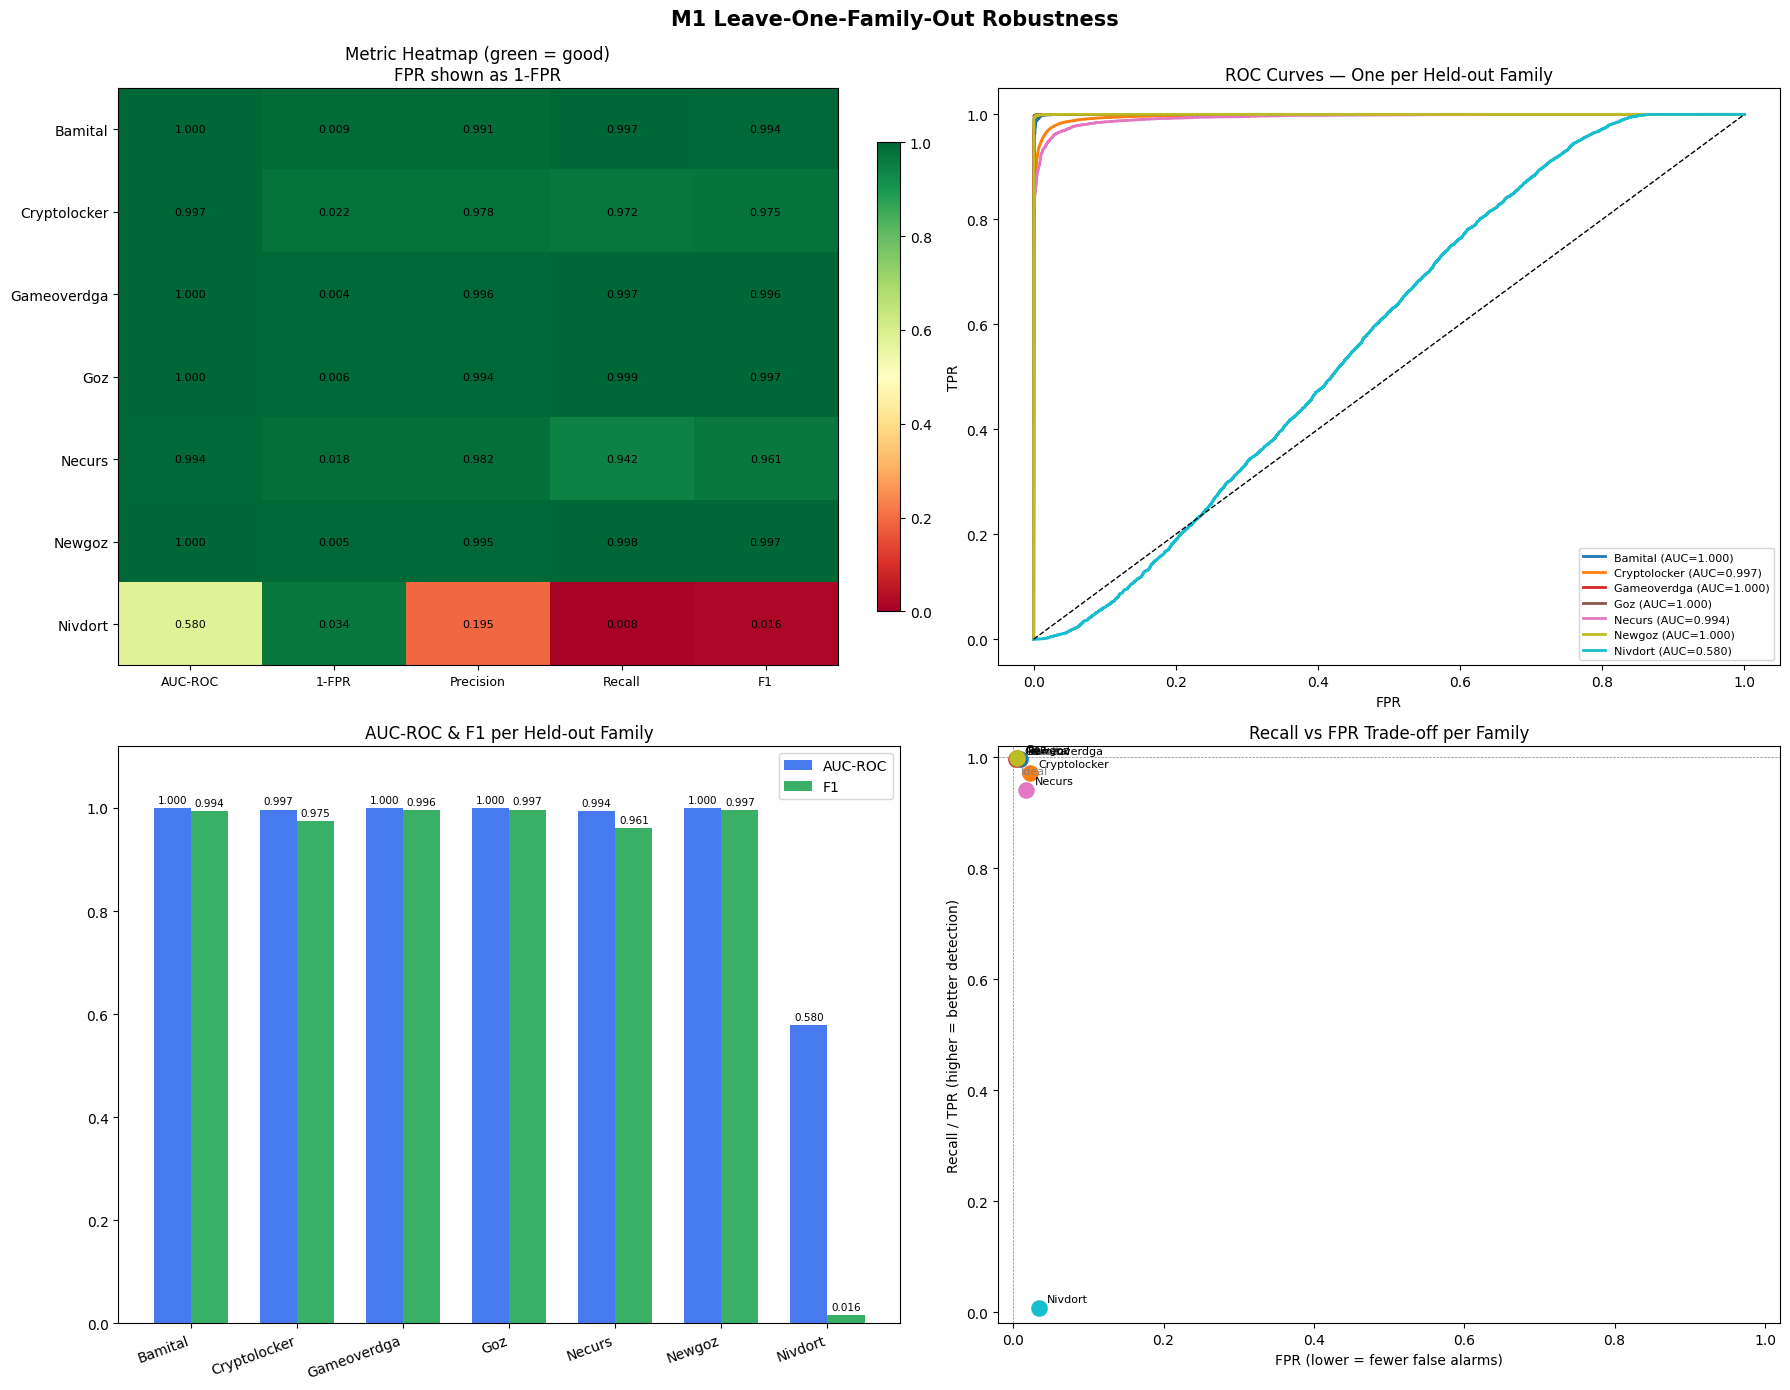

In [10]:
families    = list(DGA_FAMILIES)
family_idx  = {f: i for i, f in enumerate(families)}
METRIC_PLOT = ["AUC-ROC", "FPR", "Precision", "Recall", "F1"]

fig = plt.figure(figsize=(18, 14))
fig.suptitle("M1 Leave-One-Family-Out Robustness",
             fontsize=15, fontweight="bold", y=0.99)

# ── Metric heatmap ────────────────────────────────────────────────────────────
ax_heat = fig.add_subplot(2, 2, 1)
heat_data = np.array([
    [lofo_results[f][m] for m in METRIC_PLOT]
    for f in families
])
# Invert FPR so green = good for all metrics in the heatmap
heat_display = heat_data.copy()
fpr_col_idx  = METRIC_PLOT.index("FPR")
heat_display[:, fpr_col_idx] = 1 - heat_display[:, fpr_col_idx]

im = ax_heat.imshow(heat_display, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax_heat.set_xticks(range(len(METRIC_PLOT)))
ax_heat.set_xticklabels(
    ["AUC-ROC", "1-FPR", "Precision", "Recall", "F1"], fontsize=9
)
ax_heat.set_yticks(range(len(families)))
ax_heat.set_yticklabels([f.capitalize() for f in families])
ax_heat.set_title("Metric Heatmap (green = good)\nFPR shown as 1-FPR")
plt.colorbar(im, ax=ax_heat, fraction=0.03)

# Annotate cells
for i, f in enumerate(families):
    for j, m in enumerate(METRIC_PLOT):
        raw_val = lofo_results[f][m]
        ax_heat.text(j, i, f"{raw_val:.3f}", ha="center", va="center",
                     fontsize=8, color="black")

# ── ROC curves ────────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(2, 2, 2)
cmap   = plt.cm.get_cmap("tab10", len(families))
for i, family in enumerate(families):
    model = lofo_models[family]
    if len(np.unique(model.all_labels)) < 2:
        continue
    fpr_c, tpr_c, _ = roc_curve(model.all_labels, model.all_probs)
    auc = lofo_results[family]["AUC-ROC"]
    ax_roc.plot(fpr_c, tpr_c, color=cmap(i), lw=2,
                label=f"{family.capitalize()} (AUC={auc:.3f})")
ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC Curves — One per Held-out Family")
ax_roc.legend(fontsize=8, loc="lower right")

# ── F1 & AUC-ROC per family bar chart ─────────────────────────────────────────
ax_bar = fig.add_subplot(2, 2, 3)
x  = np.arange(len(families))
w  = 0.35
f1_vals  = [lofo_results[f]["F1"]      for f in families]
auc_vals = [lofo_results[f]["AUC-ROC"] for f in families]
ax_bar.bar(x - w/2, auc_vals, w, label="AUC-ROC", color="#2563eb", alpha=0.85)
ax_bar.bar(x + w/2, f1_vals,  w, label="F1",      color="#16a34a", alpha=0.85)
for xi, (a, f) in enumerate(zip(auc_vals, f1_vals)):
    ax_bar.text(xi - w/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=7.5)
    ax_bar.text(xi + w/2, f + 0.01, f"{f:.3f}", ha="center", fontsize=7.5)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([f.capitalize() for f in families], rotation=20, ha="right")
ax_bar.set_ylim(0, 1.12)
ax_bar.set_title("AUC-ROC & F1 per Held-out Family")
ax_bar.legend()

# ── Recall vs FPR scatter (detection power vs false alarm trade-off) ──────────
ax_scat = fig.add_subplot(2, 2, 4)
for i, family in enumerate(families):
    rec = lofo_results[family]["Recall"]
    fpr = lofo_results[family]["FPR"]
    ax_scat.scatter(fpr, rec, color=cmap(i), s=120, zorder=3, label=family.capitalize())
    ax_scat.annotate(family.capitalize(), (fpr, rec),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)
ax_scat.set_xlabel("FPR (lower = fewer false alarms)")
ax_scat.set_ylabel("Recall / TPR (higher = better detection)")
ax_scat.set_title("Recall vs FPR Trade-off per Family")
ax_scat.set_xlim(-0.02, 1.02); ax_scat.set_ylim(-0.02, 1.02)
# Ideal corner
ax_scat.axvline(0, color='grey', lw=0.5, ls='--')
ax_scat.axhline(1, color='grey', lw=0.5, ls='--')
ax_scat.text(0.01, 0.97, "Ideal", color='grey', fontsize=8)

plt.tight_layout()
plt.show()

## 10. Probability Distribution per Family

Shows the model's raw score distribution on the held-out family.
A well-separated bimodal distribution (scores pushed to 0 for benign,
1 for DGA) indicates the model generalises well to that family.

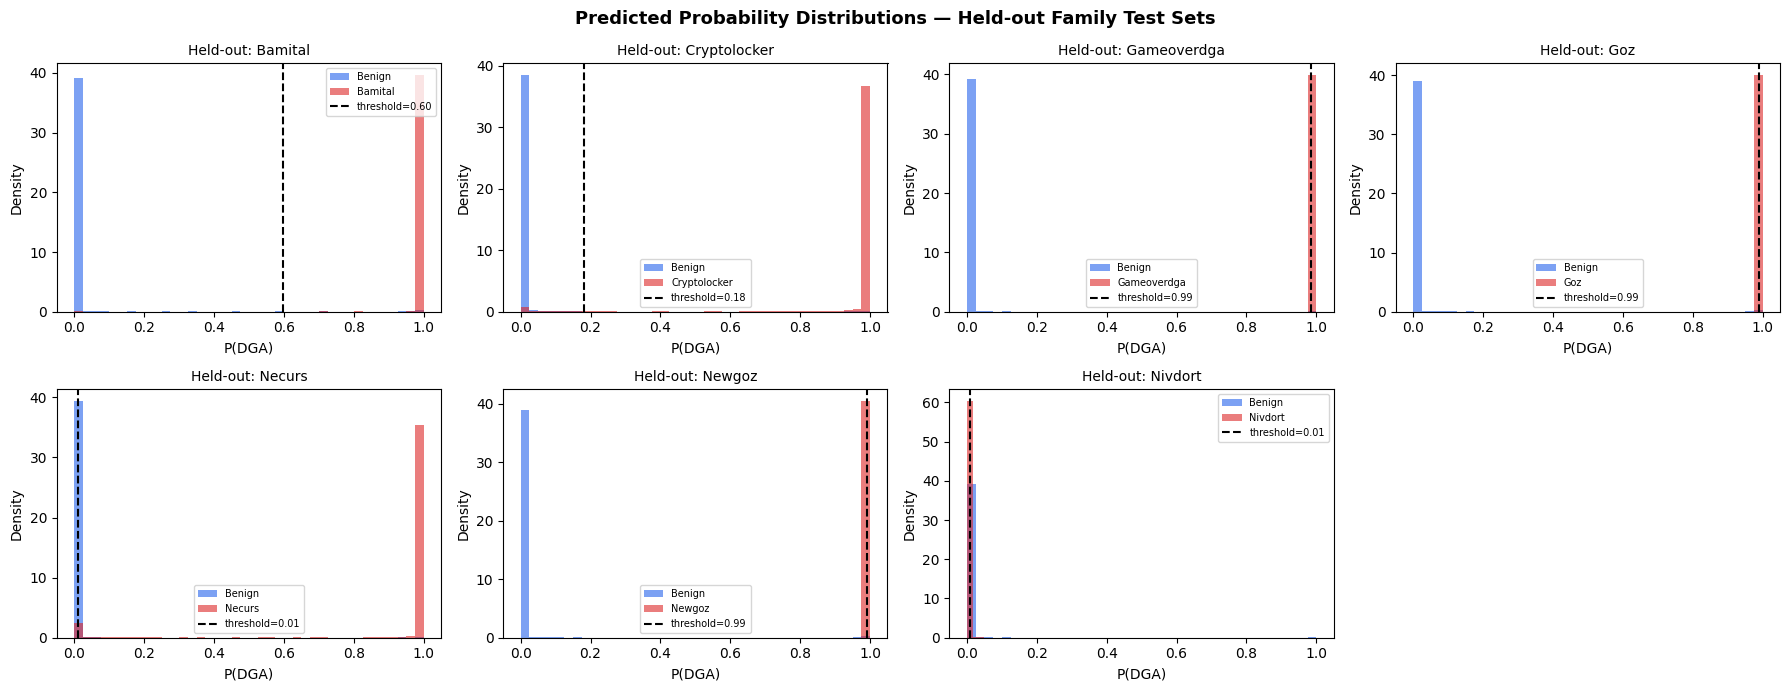

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=False)
fig.suptitle("Predicted Probability Distributions — Held-out Family Test Sets",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, family in enumerate(families):
    model  = lofo_models[family]
    probs  = model.all_probs
    labels = model.all_labels.astype(int)
    thresh = lofo_results[family]["threshold"]
    ax     = axes[i]

    ax.hist(probs[labels == 0], bins=40, alpha=0.6, color="#2563eb",
            label="Benign",  density=True)
    ax.hist(probs[labels == 1], bins=40, alpha=0.6, color="#dc2626",
            label=family.capitalize(), density=True)
    ax.axvline(thresh, color="black", ls="--", lw=1.5,
               label=f"threshold={thresh:.2f}")
    ax.set_title(f"Held-out: {family.capitalize()}", fontsize=10)
    ax.set_xlabel("P(DGA)"); ax.set_ylabel("Density")
    ax.legend(fontsize=7)

axes[-1].set_visible(False)   # hide the 8th panel (only 7 families)
plt.tight_layout()
plt.show()

## 11. Summary & Interpretation

Run this cell after the loop to get an auto-generated summary of which
families are hardest and easiest for M1 to generalise to.

In [12]:
family_f1  = {f: lofo_results[f]["F1"]      for f in families}
family_auc = {f: lofo_results[f]["AUC-ROC"] for f in families}

easiest = max(family_f1, key=family_f1.get)
hardest = min(family_f1, key=family_f1.get)

mean_f1  = np.mean(list(family_f1.values()))
mean_auc = np.mean(list(family_auc.values()))

print("="*60)
print(" M1  LEAVE-ONE-FAMILY-OUT  SUMMARY")
print("="*60)
print(f" Mean AUC-ROC across families : {mean_auc:.4f}")
print(f" Mean F1    across families   : {mean_f1:.4f}")
print()
print(f" Easiest to generalise to : {easiest.capitalize()}")
print(f"   F1={family_f1[easiest]:.4f}  AUC={family_auc[easiest]:.4f}")
print()
print(f" Hardest to generalise to : {hardest.capitalize()}")
print(f"   F1={family_f1[hardest]:.4f}  AUC={family_auc[hardest]:.4f}")
print()
print(" Per-family F1 ranking:")
for rank, (fam, score) in enumerate(
        sorted(family_f1.items(), key=lambda x: x[1], reverse=True), 1):
    bar = '█' * int(score * 30)
    print(f"  {rank}. {fam:15s} {bar} {score:.4f}")
print("="*60)

 M1  LEAVE-ONE-FAMILY-OUT  SUMMARY
 Mean AUC-ROC across families : 0.9385
 Mean F1    across families   : 0.8479

 Easiest to generalise to : Goz
   F1=0.9968  AUC=0.9997

 Hardest to generalise to : Nivdort
   F1=0.0159  AUC=0.5796

 Per-family F1 ranking:
  1. goz             █████████████████████████████ 0.9968
  2. newgoz          █████████████████████████████ 0.9965
  3. gameoverdga     █████████████████████████████ 0.9961
  4. bamital         █████████████████████████████ 0.9938
  5. cryptolocker    █████████████████████████████ 0.9749
  6. necurs          ████████████████████████████ 0.9613
  7. nivdort          0.0159


## 12. Latency Analysis

Measures **per-sample inference latency** on the held-out test set for each LOFO fold:

- **Mean latency (ms)** — average time to score one domain.
- **P99 latency (ms)** — 99th-percentile tail latency (worst-case in production).

Latency is measured by re-running the model in `eval` mode over the test `DataLoader` with `torch.no_grad()`, timing each batch and dividing by batch size to get a per-sample figure.

In [13]:
# ── Latency summary table ────────────────────────────────────────────────────
lat_df = pd.DataFrame(
    {
        fam: {
            "mean_latency_ms": lofo_results[fam]["mean_latency_ms"],
            "p99_latency_ms" : lofo_results[fam]["p99_latency_ms"],
        }
        for fam in DGA_FAMILIES
    }
).T
lat_df.index.name = "Held-out Family"

mean_lat_row = lat_df.mean(numeric_only=True).rename("MEAN")
lat_df = pd.concat([lat_df, mean_lat_row.to_frame().T])

lat_df.style \
    .background_gradient(cmap="YlOrRd", subset=["mean_latency_ms", "p99_latency_ms"]) \
    .format(precision=4) \
    .set_caption("Per-sample inference latency per LOFO fold (ms) — lower is better")


,mean_latency_ms,p99_latency_ms
bamital,0.2974,1.3711
cryptolocker,0.3339,0.5618
gameoverdga,0.2807,0.4050
goz,0.2797,0.5263
necurs,0.3585,0.5262
newgoz,0.2947,0.5821
nivdort,0.2736,0.3918
MEAN,0.3026,0.6235


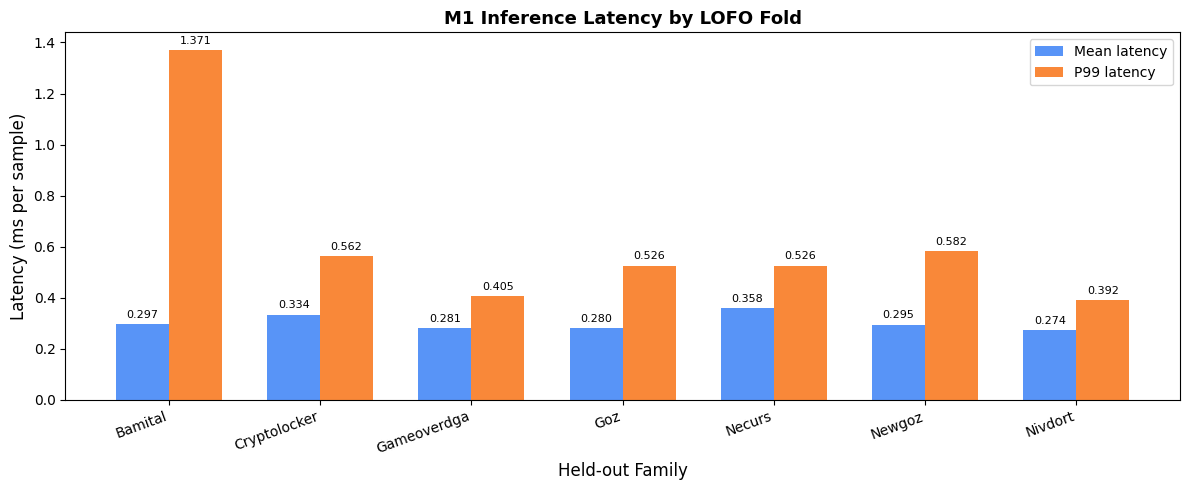


Overall mean latency : 0.3026 ms/sample
Overall P99  latency : 0.6235 ms/sample


In [14]:
# ── Latency bar chart ────────────────────────────────────────────────────────
fam_labels = list(DGA_FAMILIES)
mean_lats  = [lofo_results[f]["mean_latency_ms"] for f in fam_labels]
p99_lats   = [lofo_results[f]["p99_latency_ms"]  for f in fam_labels]

x     = np.arange(len(fam_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, mean_lats, width, label="Mean latency",  color="#3b82f6", alpha=0.85)
bars2 = ax.bar(x + width/2, p99_lats,  width, label="P99 latency",   color="#f97316", alpha=0.85)

ax.set_xlabel("Held-out Family", fontsize=12)
ax.set_ylabel("Latency (ms per sample)", fontsize=12)
ax.set_title("M1 Inference Latency by LOFO Fold", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f.capitalize() for f in fam_labels], rotation=20, ha="right")
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nOverall mean latency : {np.mean(mean_lats):.4f} ms/sample")
print(f"Overall P99  latency : {np.mean(p99_lats):.4f} ms/sample")
